In [1]:
import pandas as pd,numpy as np
import seaborn as sns, matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv(r"C:\Users\jayak\Downloads\US_Accidents_March23.csv\US_Accidents_March23.csv")

In [3]:
dfc = df.copy()
dfc.columns = dfc.columns.str.lower()

In [4]:
datetime_series = pd.to_datetime(dfc['start_time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

dfc['hours'] = datetime_series.dt.hour
dfc['day'] = datetime_series.dt.day
dfc['dayofweek'] = datetime_series.dt.day_name().astype('string')
dfc['month'] = datetime_series.dt.month
dfc['year'] = datetime_series.dt.year

In [5]:
dfc['start_time'] = pd.to_datetime(dfc['start_time'], format='%Y-%m-%d %H:%M:%S',errors ='coerce')
dfc['end_time'] = pd.to_datetime(dfc['end_time'], format='%Y-%m-%d %H:%M:%S',errors ='coerce')
dfc['duration'] = (dfc['end_time'] - dfc['start_time']).dt.total_seconds() / 60

In [6]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 51 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     object 
 1   source                 object 
 2   severity               int64  
 3   start_time             object 
 4   end_time               object 
 5   start_lat              float64
 6   start_lng              float64
 7   end_lat                float64
 8   end_lng                float64
 9   distance(mi)           float64
 10  description            object 
 11  street                 object 
 12  city                   object 
 13  county                 object 
 14  state                  object 
 15  zipcode                object 
 16  country                object 
 17  timezone               object 
 18  airport_code           object 
 19  weather_timestamp      object 
 20  temperature(f)         float64
 21  wind_chill(f)          float64
 22  humidity(%)       

In [ ]:
dfc.head()

In [8]:
dfc.isna().sum()

id                             0
source                         0
severity                       0
start_time                     0
end_time                       0
start_lat                      0
start_lng                      0
end_lat                  3402762
end_lng                  3402762
distance(mi)                   0
description                    5
street                     10869
city                         253
county                         0
state                          0
zipcode                     1915
country                        0
timezone                    7808
airport_code               22635
weather_timestamp         120228
temperature(f)            163853
wind_chill(f)            1999019
humidity(%)               174144
pressure(in)              140679
visibility(mi)            177098
wind_direction            175206
wind_speed(mph)           571233
precipitation(in)        2203586
weather_condition         173459
amenity                        0
bump      

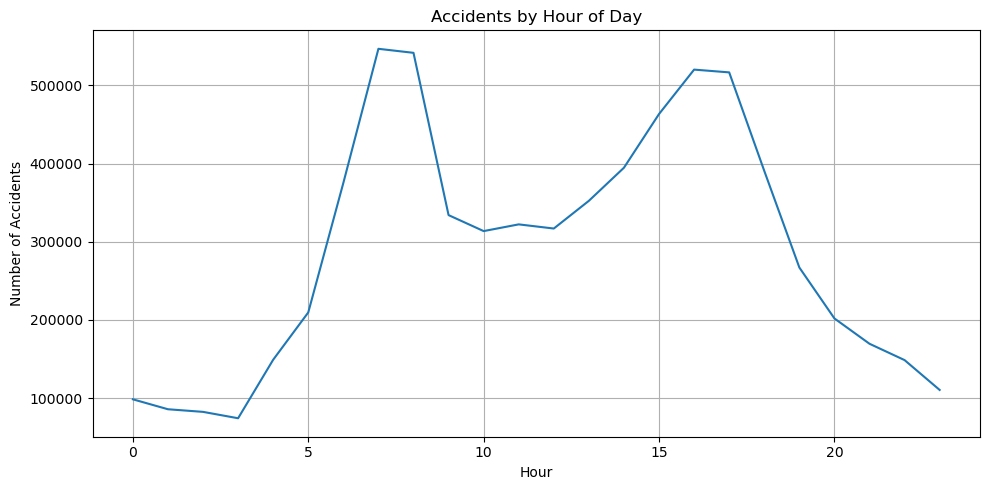

In [67]:
hourly_counts = dfc['hours'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values)
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.grid(True)
plt.tight_layout()
plt.savefig("Accidents by Hour of Day.png") 
plt.show()

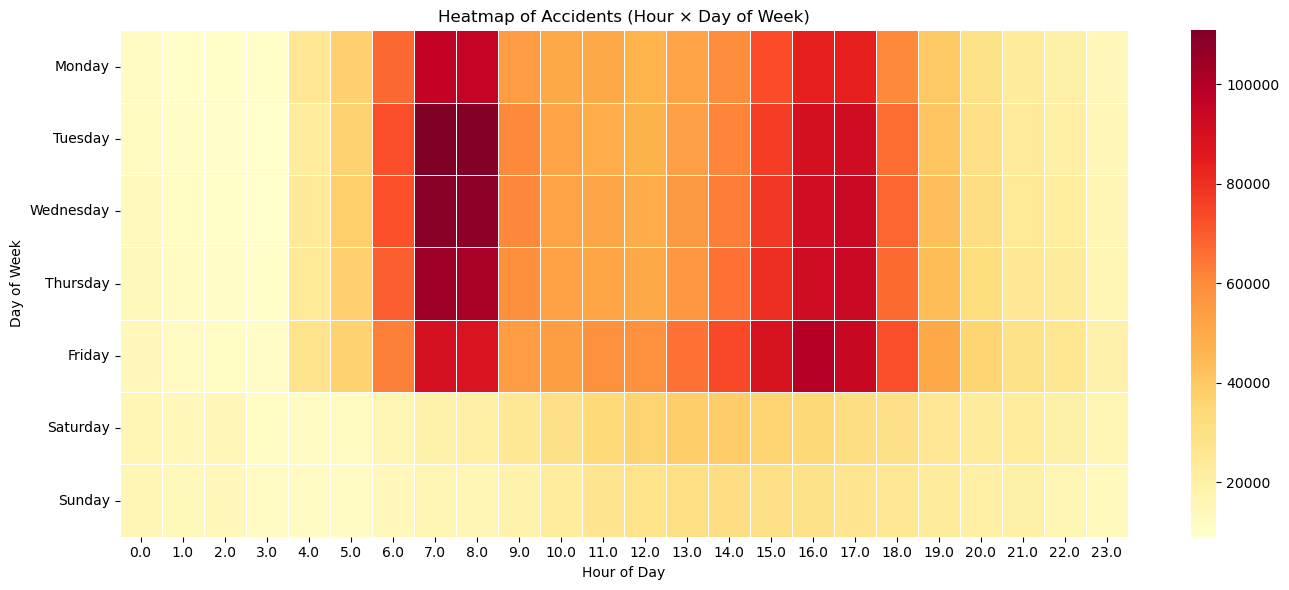

In [69]:
pivot = dfc.pivot_table(index='dayofweek', columns='hours', values='id', aggfunc='count').fillna(0)
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(ordered_days)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.5)
plt.title("Heatmap of Accidents (Hour × Day of Week)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.savefig("Heatmap of Accidents (Hour × Day of Week).png")
plt.show()

In [11]:
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}
dfc['season'] = dfc['month'].map(season_map)

In [12]:
season_severity = dfc.groupby(['season', 'severity']).size().unstack().fillna(0)

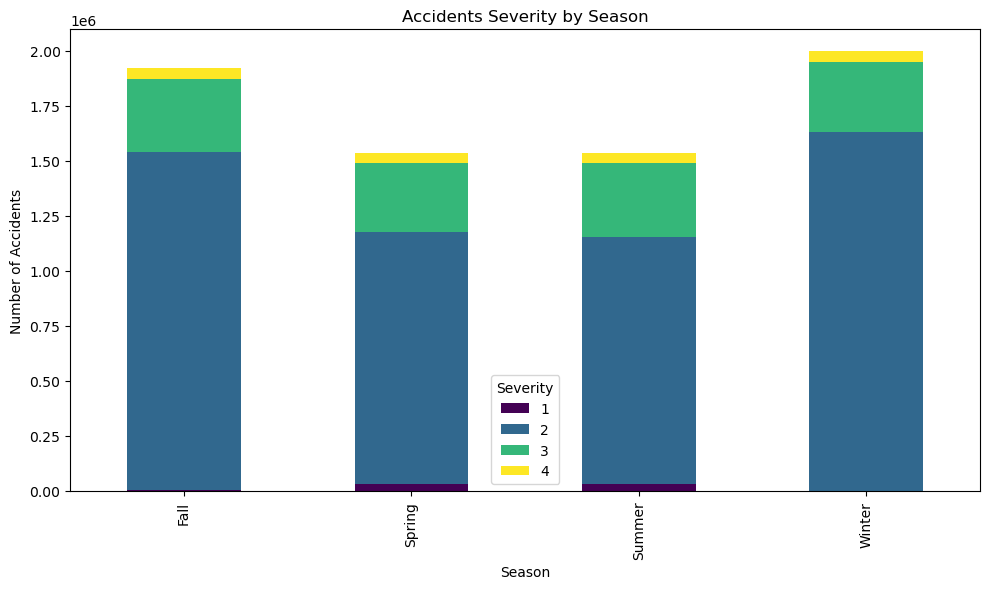

In [71]:
season_severity.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10,6))
plt.title("Accidents Severity by Season")
plt.xlabel("Season")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity")
plt.tight_layout()
plt.savefig("Accidents Severity by Season.png")
plt.show()

C:\Users\jayak\AppData\Local\Temp\ipykernel_1584\1099700351.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




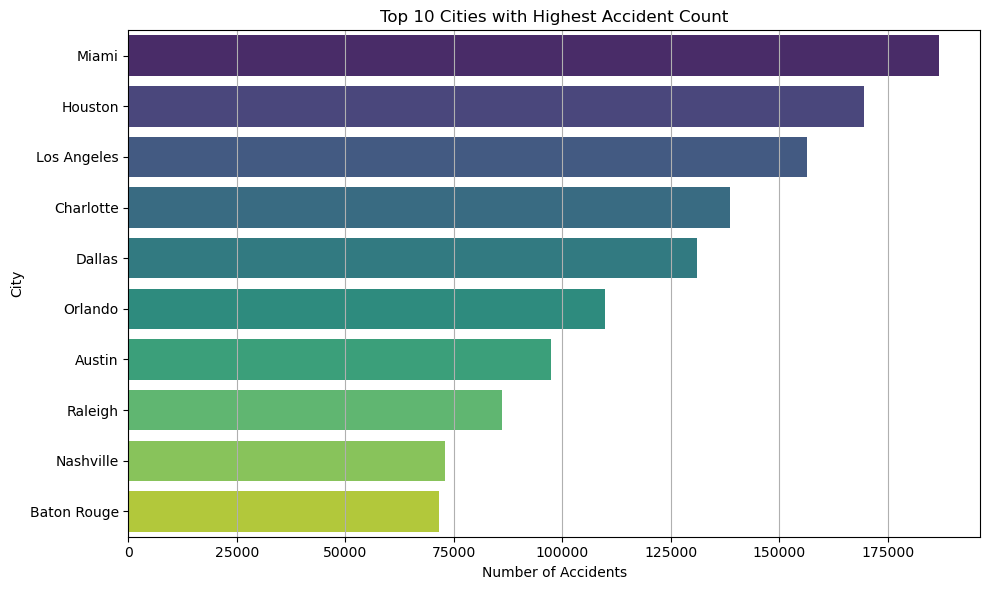

In [73]:
top_cities = dfc['city'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 10 Cities with Highest Accident Count')
plt.xlabel('Number of Accidents')
plt.ylabel('City')
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('Top 10 Cities with Highest Accident Count.png')
plt.show()

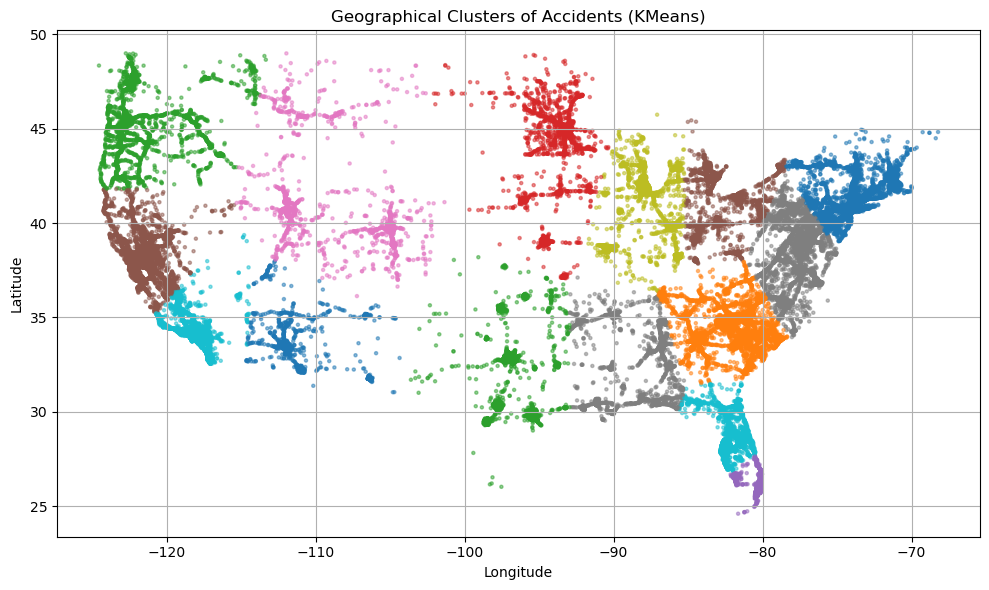

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd


df_geo = dfc[['start_lat', 'start_lng']].dropna()

# Optional: Sample for performance
df_sample = df_geo.sample(n=100000, random_state=42)

# Step 2: Fit KMeans
kmeans = KMeans(n_clusters=15, random_state=42)
df_sample['cluster'] = kmeans.fit_predict(df_sample)

# Step 3: Plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(df_sample['start_lng'], df_sample['start_lat'], 
            c=df_sample['cluster'], cmap='tab10', s=5, alpha=0.5)
plt.title('Geographical Clusters of Accidents (KMeans)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('Geographical Clusters of Accidents (KMeans).png')
plt.show()

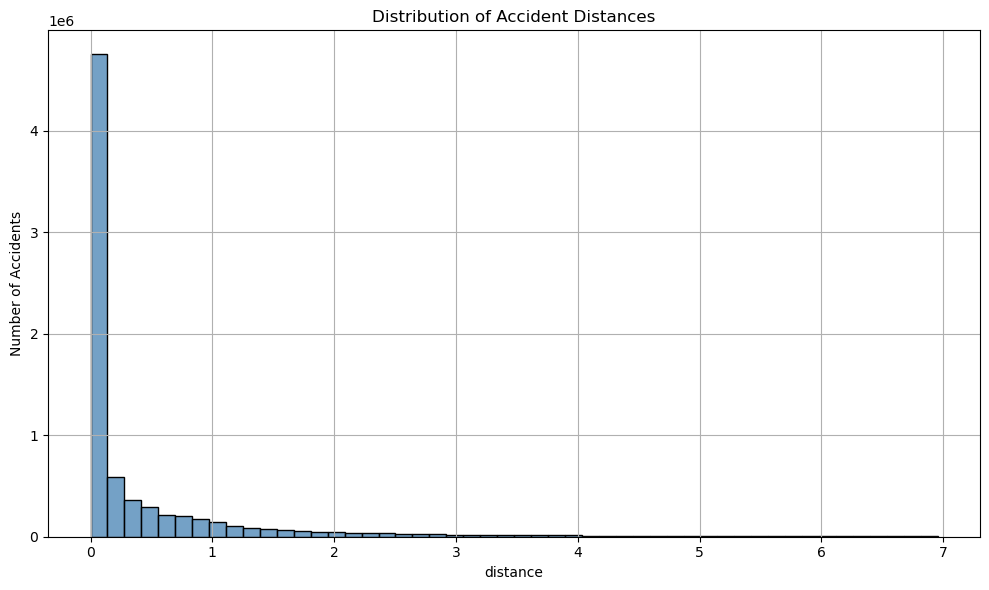

In [18]:
df_filtered = dfc[dfc['distance(mi)'] < dfc['distance(mi)'].quantile(0.99)]
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['distance(mi)'], bins=50, kde=False, color='steelblue')
plt.title('Distribution of Accident Distances')
plt.xlabel('distance')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.tight_layout()
plt.savefig('Distribution of Accident Distances.png')
plt.show()


C:\Users\jayak\AppData\Local\Temp\ipykernel_1584\2146246809.py:16: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



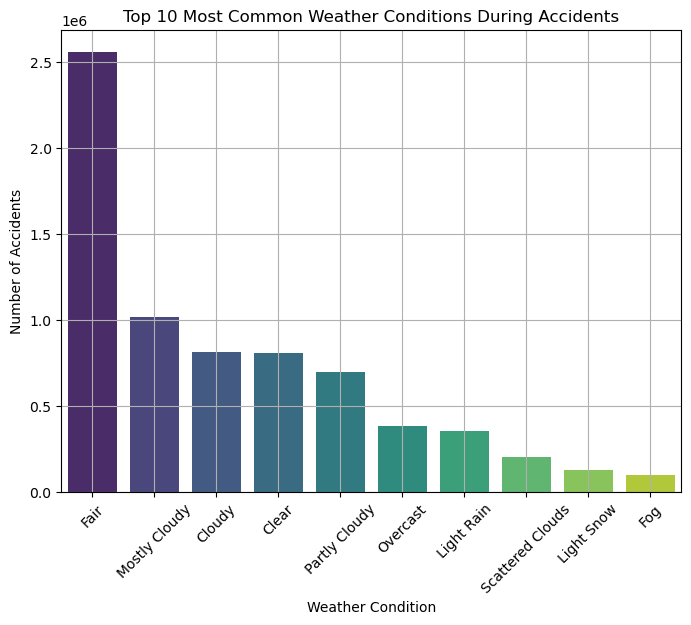

In [78]:
weather_count = dfc['weather_condition'].value_counts().reset_index()
weather_count.columns = ['Weather_Condition', 'Accident_Count']
plt.figure(figsize=(8,6))
sns.barplot(
    data=weather_count[:10], 
    x='Weather_Condition', 
    y='Accident_Count',
    hue='Weather_Condition', 
    palette='viridis',
)
plt.title('Top 10 Most Common Weather Conditions During Accidents')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend().remove()
plt.savefig('Top 10 Most Common Weather Conditions During Accidents.png')
plt.show()


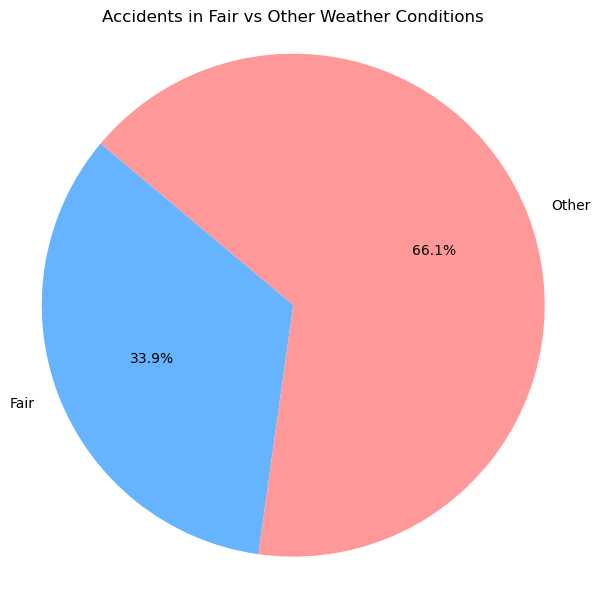

In [79]:
weather_counts = dfc['weather_condition'].value_counts()
fair_count = weather_counts.get('Fair', 0)
other_count = weather_counts.sum() - fair_count
labels = ['Fair', 'Other']
sizes = [fair_count, other_count]
colors = ['#66b3ff', '#ff9999']
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Accidents in Fair vs Other Weather Conditions')
plt.axis('equal')
plt.tight_layout()
plt.savefig('Accidents in Fair vs Other Weather Conditions.png')
plt.show()

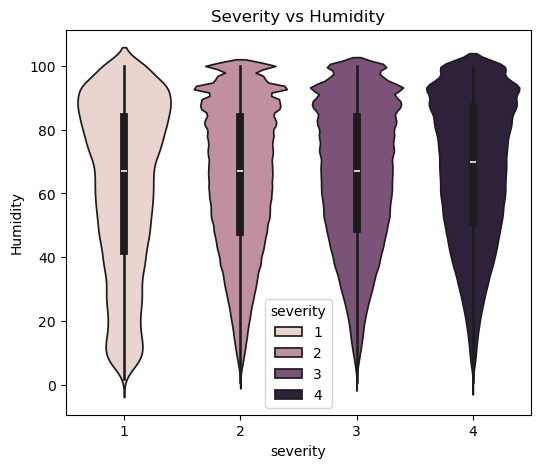

In [80]:
plt.figure(figsize = (6,5))
sns.violinplot(data = dfc, x = 'severity',y ="humidity(%)",hue ='severity')
plt.title('Severity vs Humidity')
plt.xlabel('severity')
plt.ylabel('Humidity')
plt.savefig('Severity vs Humidity.png')
plt.show()

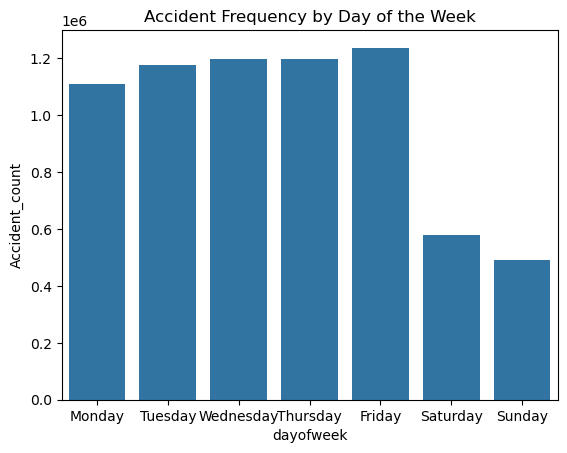

In [84]:
dayofweek_count = dfc['dayofweek'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).reset_index()
dayofweek_count.columns = ['dayofweek','Accident_count']
sns.barplot(data=dayofweek_count, x='dayofweek', y='Accident_count')
plt.title('Accident Frequency by Day of the Week')
plt.savefig('Accident Frequency by Day of the Week.png')

In [21]:
dfc.columns

Index(['id', 'source', 'severity', 'start_time', 'end_time', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'distance(mi)', 'description',
       'street', 'city', 'county', 'state', 'zipcode', 'country', 'timezone',
       'airport_code', 'weather_timestamp', 'temperature(f)', 'wind_chill(f)',
       'humidity(%)', 'pressure(in)', 'visibility(mi)', 'wind_direction',
       'wind_speed(mph)', 'precipitation(in)', 'weather_condition', 'amenity',
       'bump', 'crossing', 'give_way', 'junction', 'no_exit', 'railway',
       'roundabout', 'station', 'stop', 'traffic_calming', 'traffic_signal',
       'turning_loop', 'sunrise_sunset', 'civil_twilight', 'nautical_twilight',
       'astronomical_twilight', 'hours', 'day', 'dayofweek', 'month', 'year',
       'season'],
      dtype='object')

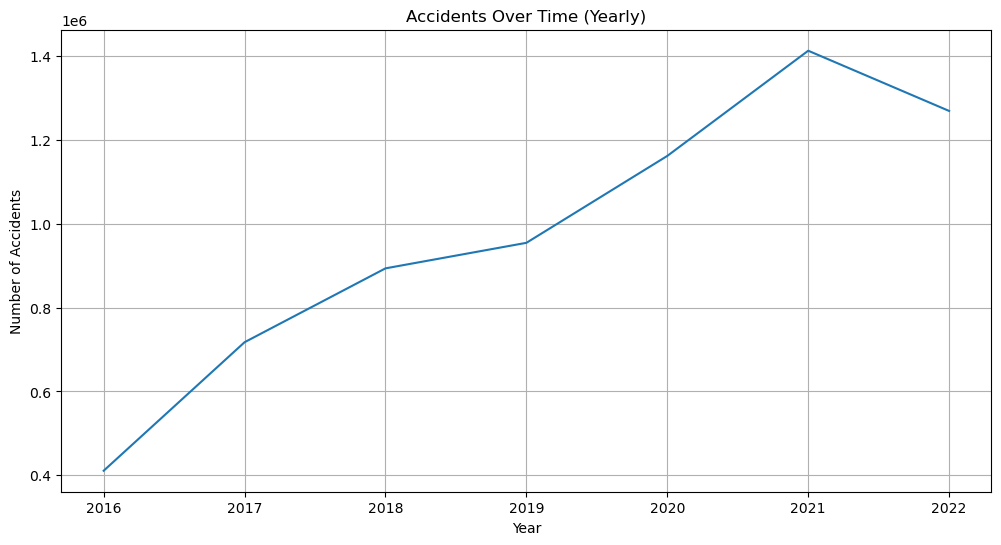

In [88]:
dfc_filtered = dfc[dfc['year'] != 2023]
yearly_accidents = dfc_filtered.groupby('year')['id'].count()
x = yearly_accidents.index.astype(int)      
y = yearly_accidents.values 
slope, intercept = np.polyfit(x, y, 1)
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_accidents.index, y=yearly_accidents.values)
plt.plot(x, slope * x + intercept, color='red', linestyle='--', label=f'Trend Line (Slope = {slope:.2f})')
plt.title('Accidents Over Time (Yearly)')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.savefig('Accidents Over Time (Yearly).png')
plt.show()

In [23]:
cols = ['amenity','bump', 'crossing', 'give_way', 'junction', 'no_exit', 
        'railway', 'roundabout', 'station', 'stop', 'traffic_calming', 
        'traffic_signal', 'turning_loop']
dfc[cols] = dfc[cols].astype(int)

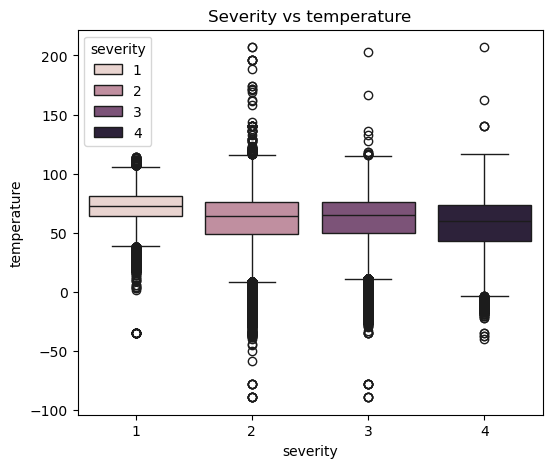

In [89]:
plt.figure(figsize = (6,5))
sns.boxplot(data = dfc, x = 'severity',y ="temperature(f)",hue ='severity')
plt.title('Severity vs temperature')
plt.xlabel('severity')
plt.ylabel('temperature')
plt.savefig('Severity vs temperature.png')
plt.show()

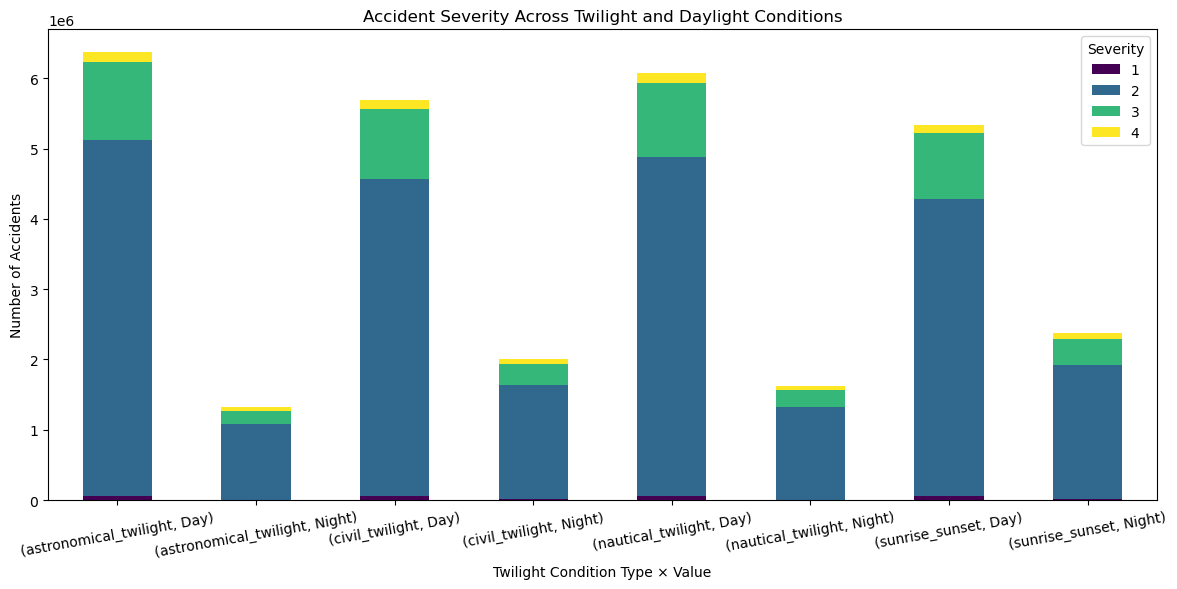

In [17]:
twilight_cols = ['sunrise_sunset', 'civil_twilight', 'nautical_twilight', 'astronomical_twilight']
df_twilight = dfc[['severity'] + twilight_cols].melt(id_vars='severity', value_vars=twilight_cols, var_name='Twilight_Type', 
                                                     value_name='Twilight_Value')
twilight_severity = df_twilight.groupby(['Twilight_Type', 'Twilight_Value', 'severity']).size().unstack().fillna(0)
twilight_severity.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Accident Severity Across Twilight and Daylight Conditions')
plt.xlabel('Twilight Condition Type × Value')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=10)
plt.legend(title='Severity')
plt.tight_layout()
plt.savefig('Accident Severity Across Twilight and Daylight Conditions.png')
plt.show()

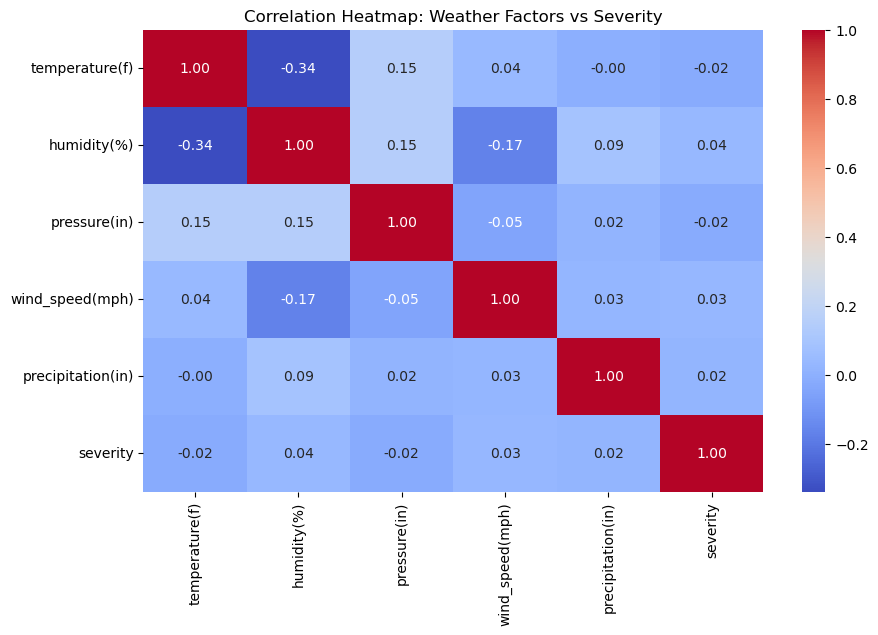

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only relevant columns
weather_cols = ['temperature(f)', 'humidity(%)', 'pressure(in)', 'wind_speed(mph)', 'precipitation(in)', 'severity']
df_weather = dfc[weather_cols].dropna()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_weather.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Weather Factors vs Severity')
plt.savefig('Correlation Heatmap: Weather Factors vs Severity.png')
plt.show()


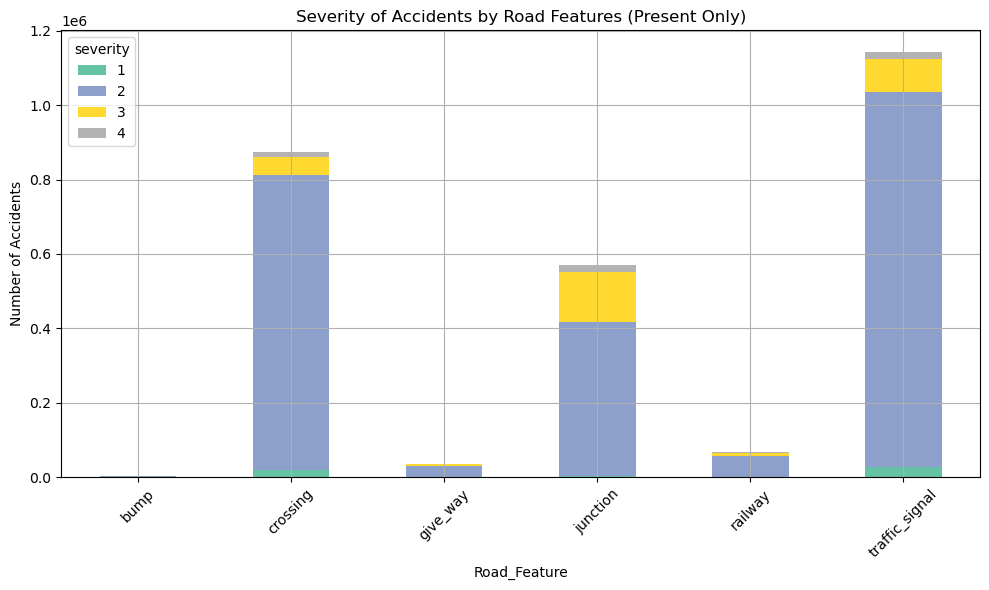

In [93]:
cols = ['junction', 'traffic_signal', 'crossing', 'bump', 'give_way', 'railway']
df_melted = dfc.melt(id_vars='severity', 
                     value_vars=cols, 
                     var_name='Road_Feature', 
                     value_name='Present')
df_present = df_melted[df_melted['Present'] == 1]
feature_severity = df_present.groupby(['Road_Feature', 'severity']).size().unstack().fillna(0)
feature_severity.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title('Severity of Accidents by Road Features (Present Only)')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('Severity of Accidents by Road Features (Present Only).png')
plt.show()



C:\Users\jayak\AppData\Local\Temp\ipykernel_1584\3957558173.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




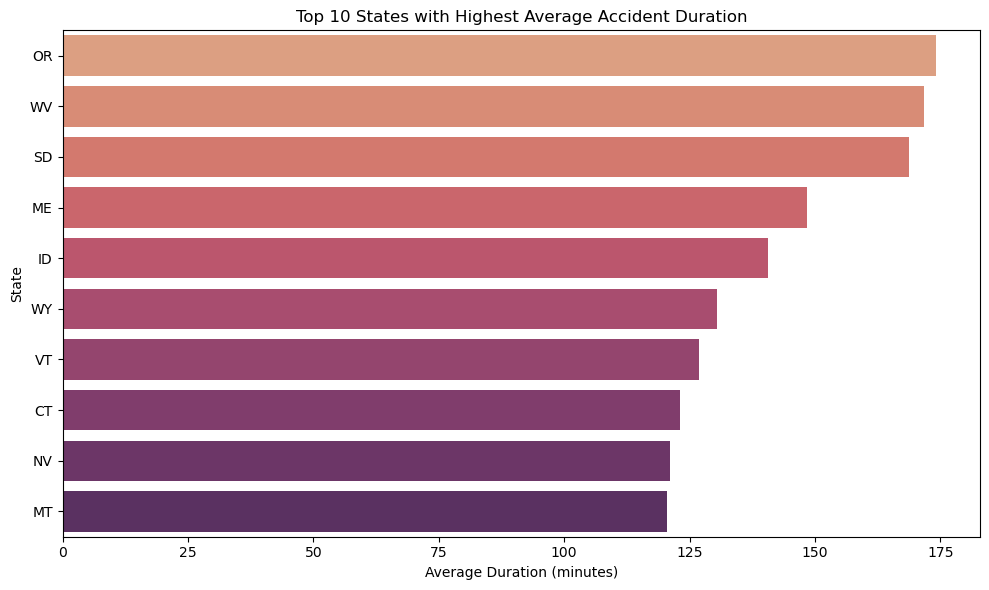

In [95]:
df_filtered = dfc[dfc['duration'] < dfc['duration'].quantile(0.99)]
state_duration = df_filtered.groupby('state')['duration'].mean().reset_index()
top10_states = state_duration.sort_values(by='duration', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_states, x='duration', y='state', palette='flare')
plt.title('Top 10 States with Highest Average Accident Duration')
plt.xlabel('Average Duration (minutes)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('Top 10 States with Highest Average Accident Duration.png')
plt.show()

In [30]:
dfc.columns

Index(['id', 'source', 'severity', 'start_time', 'end_time', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'distance(mi)', 'description',
       'street', 'city', 'county', 'state', 'zipcode', 'country', 'timezone',
       'airport_code', 'weather_timestamp', 'temperature(f)', 'wind_chill(f)',
       'humidity(%)', 'pressure(in)', 'visibility(mi)', 'wind_direction',
       'wind_speed(mph)', 'precipitation(in)', 'weather_condition', 'amenity',
       'bump', 'crossing', 'give_way', 'junction', 'no_exit', 'railway',
       'roundabout', 'station', 'stop', 'traffic_calming', 'traffic_signal',
       'turning_loop', 'sunrise_sunset', 'civil_twilight', 'nautical_twilight',
       'astronomical_twilight', 'hours', 'day', 'dayofweek', 'month', 'year',
       'season', 'duration'],
      dtype='object')

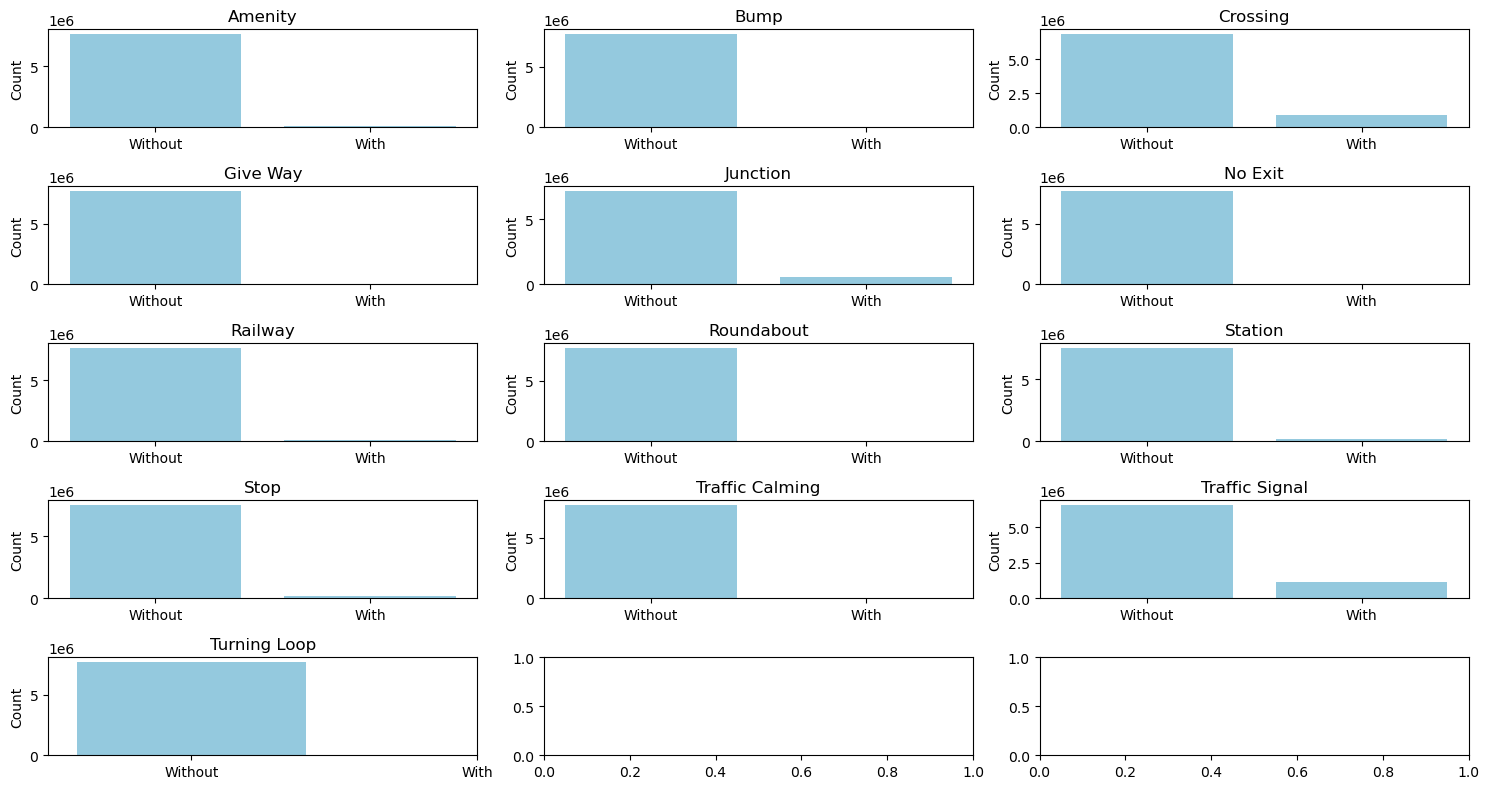

In [99]:
cols = ['amenity',
       'bump', 'crossing', 'give_way', 'junction', 'no_exit', 'railway',
       'roundabout', 'station', 'stop', 'traffic_calming', 'traffic_signal',
       'turning_loop']

# Setup subplots
fig, axs = plt.subplots(5, 3, figsize=(15, 8))
axs = axs.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=dfc, x=col, ax=axs[i], color='skyblue')
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(['Without', 'With'])
    axs[i].set_title(f"{col.replace('_', ' ').title()}")
    axs[i].set_xlabel('')
    axs[i].set_ylabel('Count')
plt.tight_layout()
plt.savefig('Traffic rules vs accident.png')
plt.show()

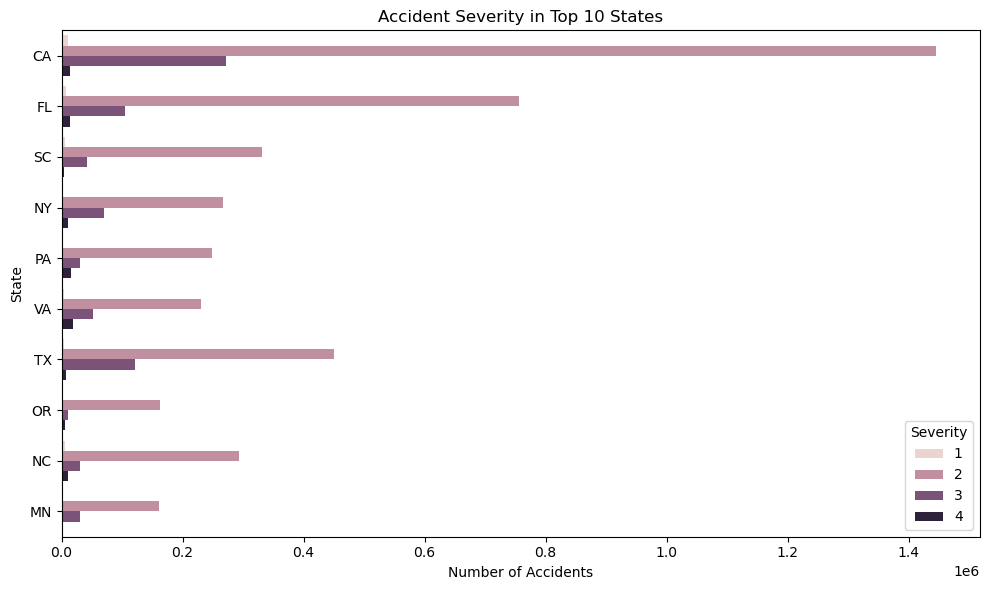

In [100]:
top_states = dfc['state'].value_counts().nlargest(10).index
df_top = dfc[dfc['state'].isin(top_states)]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_top, y='state', hue='severity')
plt.title('Accident Severity in Top 10 States')
plt.xlabel('Number of Accidents')
plt.ylabel('State')
plt.legend(title='Severity')
plt.tight_layout()
plt.savefig('Accident Severity in Top 10 States.png')
plt.show()